# Churn data: exploratory analysis

This notebook runs against `data/raw/churn_data.csv`, which is **synthetic data** generated by `scripts/make_sample_data.py` (see that file for the generation rules). It is not a real telecom dataset. Numbers below come from actually running this notebook, not from a real customer base.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 5)

## Load the data

In [2]:
df = pd.read_csv("../data/raw/churn_data.csv")
df.shape

(2000, 9)

In [3]:
df.head()

,customer_id,tenure,monthly_charges,total_charges,num_support_tickets,avg_monthly_usage,contract_type,payment_method,churn
0,CUST-000000,6,26.21,154.85,2,354,two_year,auto_pay,0
1,CUST-000001,56,65.83,3654.84,1,315,one_year,bank_transfer,0
2,CUST-000002,47,32.90,1478.37,2,400,monthly,auto_pay,0
3,CUST-000003,32,35.23,1077.42,0,473,two_year,bank_transfer,0
4,CUST-000004,31,83.23,2690.95,1,202,monthly,bank_transfer,1


In [4]:
df.dtypes

customer_id             object
tenure                   int64
monthly_charges        float64
total_charges          float64
num_support_tickets      int64
avg_monthly_usage        int64
contract_type           object
payment_method          object
churn                    int64
dtype: object

## Missing values and basic ranges

In [5]:
df.isnull().sum()

customer_id            0
tenure                 0
monthly_charges        0
total_charges          0
num_support_tickets    0
avg_monthly_usage      0
contract_type          0
payment_method         0
churn                  0
dtype: int64

In [6]:
df.describe()

,tenure,monthly_charges,total_charges,num_support_tickets,avg_monthly_usage,churn
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.00000
mean,35.990000,70.068460,2507.27012,1.450500,254.117000,0.25200
std,21.165559,28.948972,1893.43614,1.215438,141.730883,0.43427
min,0.000000,20.050000,0.00000,0.000000,10.000000,0.00000
25%,17.750000,44.630000,989.61000,1.000000,129.750000,0.00000
50%,36.000000,69.635000,2062.05500,1.000000,256.500000,0.00000
75%,55.000000,95.460000,3703.52000,2.000000,377.250000,1.00000
max,72.000000,119.980000,8744.87000,7.000000,499.000000,1.00000


## Churn rate

Churn rate: 25.2%


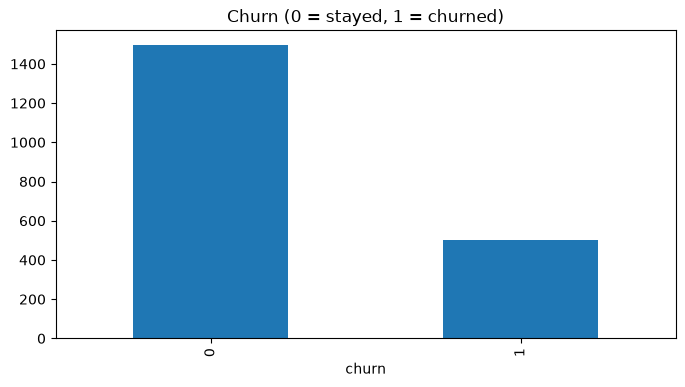

In [7]:
churn_rate = df["churn"].mean()
print(f"Churn rate: {churn_rate:.1%}")
df["churn"].value_counts().plot(kind="bar", title="Churn (0 = stayed, 1 = churned)")
plt.show()

## Tenure vs churn

The generator makes churn probability go down as tenure goes up, so this should show newer customers churning more.

In [8]:
df.groupby("churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,1496.0,39.343583,20.759612,0.0,22.0,40.0,57.0,72.0
1,504.0,26.035714,19.149997,0.0,9.0,22.0,40.0,72.0


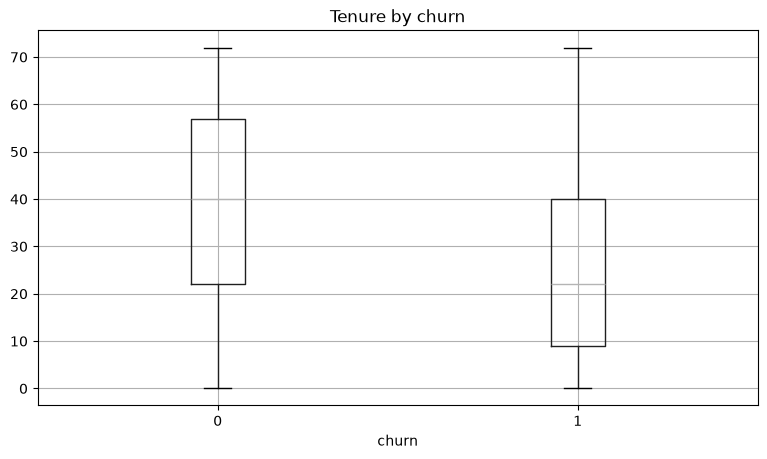

In [11]:
df.boxplot(column="tenure", by="churn")
plt.title("Tenure by churn")
plt.suptitle("")
plt.show()

## Contract type vs churn

In [14]:
contract_churn = pd.crosstab(df["contract_type"], df["churn"], normalize="index")
contract_churn

churn,0,1
contract_type,,
monthly,0.639299,0.360701
one_year,0.853968,0.146032
two_year,0.926573,0.073427


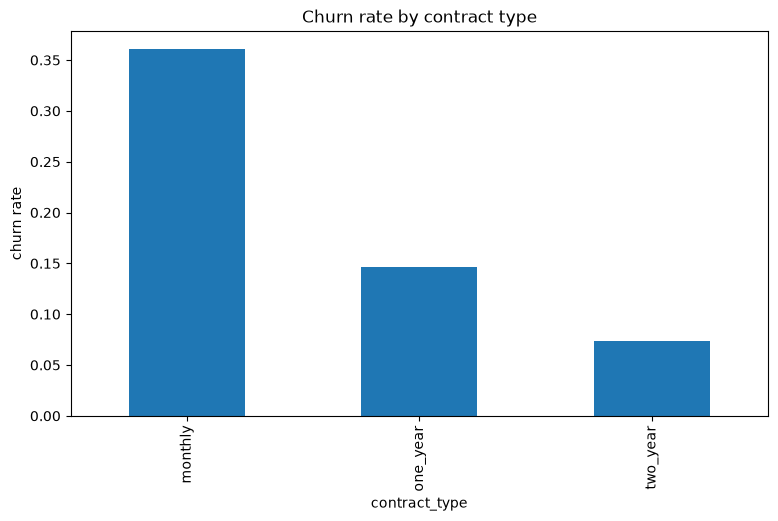

In [13]:
contract_churn[1].sort_values(ascending=False).plot(
    kind="bar", title="Churn rate by contract type"
)
plt.ylabel("churn rate")
plt.show()

## Support tickets vs churn

In [15]:
df.groupby("churn")["num_support_tickets"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,1496.0,1.379679,1.150350,0.0,1.0,1.0,2.0,7.0
1,504.0,1.660714,1.370654,0.0,1.0,1.0,3.0,7.0


## Correlation between numerical features

In [16]:
numerical_cols = [
    "tenure", "monthly_charges", "total_charges",
    "num_support_tickets", "avg_monthly_usage", "churn",
]
df[numerical_cols].corr()

,tenure,monthly_charges,total_charges,num_support_tickets,avg_monthly_usage,churn
tenure,1.000000,-0.017980,0.771086,-0.020826,0.022782,-0.273048
monthly_charges,-0.017980,1.000000,0.526681,-0.019524,0.001874,0.097040
total_charges,0.771086,0.526681,1.000000,-0.009539,0.013955,-0.173924
num_support_tickets,-0.020826,-0.019524,-0.009539,1.000000,-0.032630,0.100412
avg_monthly_usage,0.022782,0.001874,0.013955,-0.032630,1.000000,-0.009143
churn,-0.273048,0.097040,-0.173924,0.100412,-0.009143,1.000000


## Is total_charges redundant?

`total_charges` should track `tenure * monthly_charges`. If it does, it adds little on top of the two columns it comes from.

In [18]:
implied = df["tenure"] * df["monthly_charges"]
print(f"corr(total_charges, tenure * monthly_charges): {df['total_charges'].corr(implied):.4f}")
print(f"mean absolute gap: {(df['total_charges'] - implied).abs().mean():.2f}")

corr(total_charges, tenure * monthly_charges): 0.9955
mean absolute gap: 123.92


## Takeaways

- Churn correlates with short tenure and month-to-month contracts, matching the rules the generator uses (`scripts/make_sample_data.py`).
- `contract_type` and `tenure` look like the strongest signals here, which lines up with `feature_engineering.py` deriving `tenure_bucket` and `lifetime_value` from tenure.
- Next step is `src/train.py`, which trains on this same file.
- `total_charges` is almost a product of `tenure` and `monthly_charges` (r = 0.996), so it is close to redundant once both are in the model.